In [1]:
import numpy as np
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
import torch
import torch.nn.functional as functional
from matplotlib import pyplot as plt

In [2]:
X, y = make_moons(1000, noise=0.2)
Q = train_test_split(X, y)

In [3]:
for i, q in enumerate(Q):
    Q[i] = torch.from_numpy(q).to(dtype = torch.float)

test_x, train_x, test_y, train_y = Q
train_dataset = torch.utils.data.TensorDataset(train_x, train_y)
test_dataset = torch.utils.data.TensorDataset(test_x, test_y)

train_dataset = torch.utils.data.DataLoader(train_dataset, 20)
test_dataset = torch.utils.data.DataLoader(test_dataset, 20)



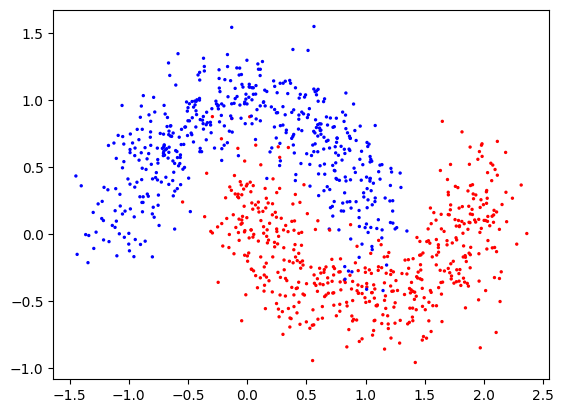

In [4]:
plt.scatter(X[:, 0], X[:, 1], c=np.where(y == 1, 'red', 'blue'), s = 2)
plt.show()

In [5]:
from typing import Iterator


from torch.nn.parameter import Parameter


def fit(model:torch.nn.Module, optimizer:torch.optim.Optimizer, train_data, loss_funciton):
    total_loss = 0
    model.train(True)

    for X, y in train_data:
        loss = loss_funciton(model(X), y)
        total_loss += loss.item()
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    model.train(False)
    return total_loss/len(train_data)

def test(model, test_data, loss_funciton):
    total_loss = 0

    for X, y in test_data:
        loss = loss_funciton(model(X), y)
        total_loss += loss.item()
    
    return total_loss/len(test_data)


class model(torch.nn.Module):
    def __init__(self, dropout_p = 0.2) -> None:
        super().__init__()
        self.l1 = torch.nn.Linear(2, 3)
        self.l2 = torch.nn.Linear(3, 3)
        self.l3 = torch.nn.Linear(3, 1)

        self.dropout = torch.nn.Dropout(dropout_p)

    def forward(self, x):
        o = functional.rrelu(self.l1(x))
        if self.training:
            o = self.dropout(o)
        o = functional.rrelu(self.l2(o))
        if self.training:
            o = self.dropout(o)
        o = functional.rrelu(self.l3(o))
        return torch.flatten(functional.sigmoid(o), 0)

In [6]:
loss_funciton = torch.nn.BCELoss()
m = model(0.0)
optim = torch.optim.SGD(m.parameters(), lr = 0.1)

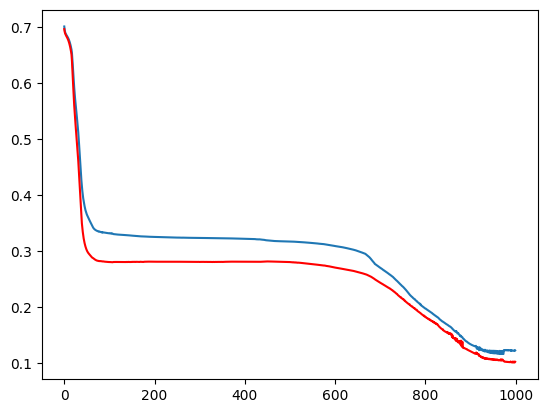

In [7]:
H = []
H1 = []
for _ in range(1000):
    H.append(fit(m, optim, train_dataset, loss_funciton))
    H1.append(test(m, test_dataset, loss_funciton))

plt.plot(H)
plt.plot(H1, color='red')
plt.show()

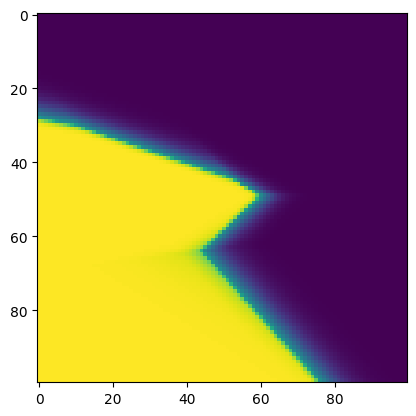

In [8]:
xi = np.linspace(-3, 3, 100)
yi = np.linspace(-3, 3, 100)

Q = []
for e1 in xi:
    O = []
    for e2 in yi:
        O.append(m(torch.tensor([e1, e2], dtype = torch.float)).item())
    Q.append(O)

plt.imshow(Q)
#plt.scatter(40*(X[:, 0]/3 + 1), 40*(X[:, 1]/3 + 1), c=np.where(y == 1, 'red', 'blue'), s = 2)
plt.show()